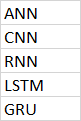

In [ ]:
# Updated: Train & evaluate ANN, CNN, RNN, LSTM, GRU with tuned hyperparams
# -------------------------------------------------------------------
# Requirements: pandas, numpy, scikit-learn, tensorflow (2.x)
# -------------------------------------------------------------------

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, cohen_kappa_score, matthews_corrcoef, confusion_matrix
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten,
    Conv1D, MaxPooling1D, SimpleRNN, LSTM, GRU, Input, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------
# Load dataset
# -------------------------
DATA_PATH = "/content/prott5_small_dataset_for_check.csv"
df = pd.read_csv(DATA_PATH)

TARGET_COL = "label"
X = df.drop(TARGET_COL, axis=1).values
y = df[TARGET_COL].values.astype(int)

# -------------------------
# Train-test split & scaling
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

TIMESTEPS = 1
n_features = X_train.shape[1]
X_train_rnn = X_train.reshape((X_train.shape[0], TIMESTEPS, n_features))
X_test_rnn  = X_test.reshape((X_test.shape[0], TIMESTEPS, n_features))

# -------------------------
# Metrics
# -------------------------
def compute_metrics(y_true, y_pred_labels, y_pred_probs):
    acc = accuracy_score(y_true, y_pred_labels)
    prec = precision_score(y_true, y_pred_labels, zero_division=0)
    rec = recall_score(y_true, y_pred_labels, zero_division=0)
    f1 = f1_score(y_true, y_pred_labels, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_probs)
    kappa = cohen_kappa_score(y_true, y_pred_labels)
    mcc = matthews_corrcoef(y_true, y_pred_labels)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_labels).ravel()
    specificity = tn / (tn + fp)
    return {"Accuracy": acc, "Precision": prec, "Recall": rec,
            "F1": f1, "Specificity": specificity, "AUC": auc,
            "Kappa": kappa, "MCC": mcc}

# -------------------------
# Training utility
# -------------------------
def compile_and_train(model, X_tr, y_tr, epochs=100, batch_size=32, val_split=0.2):
    es = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1)
    rl = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, verbose=1, min_lr=1e-6)
    history = model.fit(
        X_tr, y_tr,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=val_split,
        callbacks=[es, rl],
        verbose=1
    )
    return history

# -------------------------
# Tuned Models
# -------------------------

def build_ann(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn(timesteps, features):
    model = Sequential([
        Input(shape=(timesteps, features)),
        Conv1D(filters=128, kernel_size=1, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Conv1D(filters=64, kernel_size=1, activation='relu'),
        MaxPooling1D(pool_size=1),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_simple_rnn(timesteps, features):
    model = Sequential([
        Input(shape=(timesteps, features)),
        SimpleRNN(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_lstm(timesteps, features):
    model = Sequential([
        Input(shape=(timesteps, features)),
        LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_gru(timesteps, features):
    model = Sequential([
        Input(shape=(timesteps, features)),
        GRU(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.2),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# -------------------------
# Run All Models
# -------------------------
models_info = [
    {"name": "ANN", "builder": lambda: build_ann(n_features), "input": ("flat", X_train, X_test)},
    {"name": "CNN_1D", "builder": lambda: build_cnn(TIMESTEPS, n_features), "input": ("rnn", X_train_rnn, X_test_rnn)},
    {"name": "RNN_Simple", "builder": lambda: build_simple_rnn(TIMESTEPS, n_features), "input": ("rnn", X_train_rnn, X_test_rnn)},
    {"name": "RNN_LSTM", "builder": lambda: build_lstm(TIMESTEPS, n_features), "input": ("rnn", X_train_rnn, X_test_rnn)},
    {"name": "RNN_GRU", "builder": lambda: build_gru(TIMESTEPS, n_features), "input": ("rnn", X_train_rnn, X_test_rnn)},
]

results_list = []

for info in models_info:
    print(f"\n\n===== Training {info['name']} =====\n")
    model = info["builder"]()
    _, X_tr, X_te = info["input"]
    compile_and_train(model, X_tr, y_train, epochs=120, batch_size=32, val_split=0.2)
    y_prob = model.predict(X_te).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Model"] = info["name"]
    results_list.append(metrics)

results_df = pd.DataFrame(results_list)
results_df.to_csv("Deep_learning_model_results_for_prott5.csv", index=False)
print(results_df)




===== Training ANN =====

Epoch 1/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.5604 - loss: 0.8536 - val_accuracy: 0.6875 - val_loss: 0.6773 - learning_rate: 1.0000e-04
Epoch 2/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5802 - loss: 0.7931 - val_accuracy: 0.6562 - val_loss: 0.6464 - learning_rate: 1.0000e-04
Epoch 3/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6094 - loss: 0.7731 - val_accuracy: 0.6562 - val_loss: 0.6163 - learning_rate: 1.0000e-04
Epoch 4/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5875 - loss: 0.7295 - val_accuracy: 0.7188 - val_loss: 0.5862 - learning_rate: 1.0000e-04
Epoch 5/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6854 - loss: 0.6181 - val_accuracy: 0.7188 - val_loss: 0.5584 - learning_rate: 1.0000e-04
Epoch 6/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6885 - loss: 0.6402 - val_accuracy: 0.7188 - val_loss: 0.5329 - learning_rate: 1.0000e-04
Epoch 7/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/st

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


===== Training RNN_LSTM =====

Epoch 1/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 289ms/step - accuracy: 0.4010 - loss: 0.7385 - val_accuracy: 0.5625 - val_loss: 0.6946 - learning_rate: 1.0000e-04
Epoch 2/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5135 - loss: 0.7040 - val_accuracy: 0.5938 - val_loss: 0.6762 - learning_rate: 1.0000e-04
Epoch 3/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6531 - loss: 0.6544 - val_accuracy: 0.6250 - val_loss: 0.6589 - learning_rate: 1.0000e-04
Epoch 4/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6833 - loss: 0.6292 - val_accuracy: 0.6562 - val_loss: 0.6424 - learning_rate: 1.0000e-04
Epoch 5/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6500 - loss: 0.6315 - val_accuracy: 0.7500 - val_loss: 0.6269 - learning_rate: 1.0000e-04
Epoch 6/120
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6750 - loss: 0.6248 - val_accuracy: 0.7500 - val_loss: 0.6122 - learning_rate: 1.0000e-04
Epo